
## ISO BIMODAL ANALYSIS SUITE (MJO & BSISO) 

MJO(Madden-Julian Oscillation) and BSISO(Boreal Summer Intraseasonal Oscillation)

Creator: Arnold Sullivan & GEMINI AI Collaborator<br>
Version: 3.2 (Bimodal Competition Logic)<br>
Date: 05-02-2026<br>
Documentation: NaN <br>

Edited to notebook version with ESMValCore Dataset: 08-05-2026, Felicity Chun

#### LOGIC OVERVIEW:
1. SPATIAL WEIGHTING: Uses sqrt(cos(lat)) to account for grid-cell area changes,
   ensuring the poles are not over-represented during PCA.
2. SEASONAL INDEPENDENCE: Per scientific convention (Kikuchi et al. 2012), the MJO 
   patterns are derived from DJF data, while BSISO is derived from JJA data.
3. BIMODAL COMPETITION: The script projects the entire year of data onto these 
   fixed seasonal EEOFs to determine which mode is physically predominant 
   during transition months (May, November).
4. SIGN CONVENTION: Manual sign-flipping is applied to PC/EOF pairs to ensure 
   convection patterns match established paper conventions (e.g., EOF1 showing 
   negative OLR/active convection over the Indian Ocean).

#### FUNCTION REFERENCE:
* lanczos_bandpass_filter: Isolates the 25-90 day signal using a Lanczos 
  window to avoid Gibbs oscillation. Corrects for filter phase lag.
* calculate_eeof: Constructs the lagged data matrix (EEOF), performs area-
  weighted PCA, and normalises PCs to unit variance.
* project_entire_year: A "Projector" function that takes year-round data and 
  maps it onto fixed seasonal "fingerprints" to calculate daily ISO amplitude.
* plot_phase_space: Generates the 8-phase wheel with geographical annotations 
  specific to MJO (equatorial) vs BSISO (off-equator) propagation.

REFERENCES:

1. The Original Bimodal Index Paper (2012)
This paper introduced the original EEOF-based index using 3-month solstice seasons (DJF and JJA) to define the MJO and BSISO modes.
   - **APA:** Kikuchi, K., Wang, B., & Kajikawa, Y. (2012). Bimodal representation of the tropical intraseasonal oscillation. *Climate Dynamics*, *38*, 1989-2000.
   - **DOI:** 10.1007/s00382-011-1159-1

2. The JRA-55 Extension & Revision Paper (2020)
This study extended the index back to 1958 using reanalysis data and updated the methodology to use **extended seasons** (December-April and June-October) for the EEOF analysis.
   - **APA:** Kikuchi, K. (2020). Extension of the bimodal intraseasonal oscillation index using JRA-55 reanalysis. *Climate Dynamics*, *54*, 919-933.
   - **Key Update:** This paper justifies the switch from 3-month to 5-month seasons to represent the ISO more faithfully throughout the year.

3. The BSISO Review Paper (2021)
This comprehensive review summarizes the fundamental features, theories, and simulation status of the BSISO, using the bimodal index as a consistent baseline for analysis.
   - **APA:** Kikuchi, K. (2021). The boreal summer intraseasonal oscillation: A review. *Journal of the Meteorological Society of Japan*, *99*(4), 933-972.
   - **DOI:** 10.2151/jmsj.2021-045

In [ ]:
import dask.distributed as dask

client = dask.Client(threads_per_worker = 1)
client

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.decomposition import PCA
from scipy.signal import firwin, lfilter

from esmvalcore.dataset import Dataset
from esmvalcore.preprocessor import (
    extract_region, 
    extract_season,
    anomalies,
)

## Find data

In [ ]:
mod = Dataset(
    short_name='rlut', project='CMIP6', activity='*',
    mip="day", exp="piControl", ensemble="r1i1p1f1",
    timerange="*", dataset="ACCESS-ESM1-5", grid="gn"
)
# mod.files

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/esmvalcore/config/_config.py:49: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/ESMValCore/pull/2747 for details). To silent this warning and ignore deprecated extra facets, set the environment variable ESMVALTOOL_USE_NEW_EXTRA_FACETS_CONFIG=1.
  warn_if_old_extra_facets_exist()


[LocalFile('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/day/rlut/gn/v20191202/rlut_day_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_02960101-03251231.nc')]

In [ ]:
#
def lanczos_bandpass_filter(cube_anom, low=25, high=90, window=139):
    """Applies a Lanczos band-pass filter to the data."""
    da = xr.DataArray.from_iris(cube_anom).chunk(dict(time=-1))
    
    f_high, f_low = 1.0/low, 1.0/high
    weights = firwin(window, [f_low, f_high], pass_zero=False, fs=1.0)
    def apply_fir(x): return lfilter(weights, 1, x, axis=0)
    filtered = xr.apply_ufunc(apply_fir, da, input_core_dims=[["time"]],
                              output_core_dims=[["time"]], vectorize=True, dask="parallelized")
    return filtered.shift(time=-(window // 2))

In [ ]:
# 1. Spatial Subset and Anomalies
rlut = mod.load()
rlut = extract_region(rlut, start_longitude=-180, end_longitude=180, start_latitude=-30, end_latitude=30)

rlut_anom = anomalies(rlut, period="daily")
rlut_filtered = lanczos_bandpass_filter(rlut_anom).dropna("time")

 rlut: attribute positive not present
loaded from file 
/jobfs/167752003.gadi-pbs/ipykernel_367832/2995272533.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  da = xr.DataArray.from_iris(cube_anom).chunk(dict(time=-1))
/jobfs/167752003.gadi-pbs/ipykernel_367832/2995272533.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  da = xr.DataArray.from_iris(cube_anom).chunk(dict(time=-1))


In [ ]:
# xr.DataArray.from_iris(rlut_anom).chunk(dict(time=-1))
rlut_filtered

<xarray.DataArray 'rlut' (lat: 49, lon: 192, time: 10887)> Size: 819MB
dask.array<getitem, shape=(49, 192, 10887), dtype=float64, chunksize=(49, 96, 10887), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 392B -30.0 -28.75 -27.5 -26.25 ... 27.5 28.75 30.0
  * lon      (lon) float64 2kB -180.0 -178.1 -176.2 -174.4 ... 174.4 176.2 178.1
  * time     (time) object 87kB 0296-01-01 12:00:00 ... 0325-10-22 12:00:00
Attributes: (12/52)
    standard_name:          toa_outgoing_longwave_flux
    long_name:              TOA Outgoing Longwave Radiation
    units:                  W m-2
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    version:                v20191202
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/3f6bae96-38c6-4866-b9c9-23bbe3bcbf8c
    license:                CMIP6 model data produced by CSIRO is licensed un...
    comment:                at the top of the atmosphere (to be compared with...
    cell_methods:           area: time: mean

In [ ]:
def calculate_eeof(da_seasonal, lat_name, lon_name, lags=[-10, -5, 0]):
    """Performs Extended EOF (EEOF) analysis."""
    lagged_list = []
    for lag in lags:
        shifted = da_seasonal.shift(time=-lag)
        shifted = shifted.expand_dims(lag=[lag])
        lagged_list.append(shifted)
    
    extended_da = xr.concat(lagged_list, dim='lag').dropna('time', how='any')
    
    # Area-weighting by sqrt(cos(lat))
    weights = np.sqrt(np.cos(np.deg2rad(extended_da[lat_name])))
    weighted_da = extended_da * weights
    
    n_lag, n_lat, n_lon = len(lags), len(da_seasonal[lat_name]), len(da_seasonal[lon_name])
    n_time = len(extended_da.time)
    
    # Flattening for PCA
    matrix = weighted_da.transpose('time', 'lag', lat_name, lon_name).values.reshape(n_time, -1)
    
    pca = PCA(n_components=2)
    pcs_raw = pca.fit_transform(matrix) 
    var_exp = pca.explained_variance_ratio_ * 100
    
    # Unit Variance Normalization
    pc_std = pcs_raw.std(axis=0)
    pcs_normalized = pcs_raw / pc_std
    eeofs_scaled = pca.components_ * pc_std[:, np.newaxis]
    
    # Reconstruct into Xarray
    eeof_da = xr.DataArray(
        eeofs_scaled.reshape(2, n_lag, n_lat, n_lon),
        coords={'mode': [0, 1], 'lag': lags, lat_name: da_seasonal[lat_name].values, lon_name: da_seasonal[lon_name].values},
        dims=['mode', 'lag', lat_name, lon_name]
    )
    
    pc_da = xr.DataArray(
        pcs_normalized,
        coords={'time': extended_da.time.values, 'mode': [1, 2]},
        dims=['time', 'mode']
    )
    return eeof_da, pc_da, var_exp

In [ ]:
# 2. Seasonal Selection & EEOF Calculation
lags = [-10, -5, 0]
mjo_data = rlut_filtered.sel(time=rlut_filtered.time.dt.month.isin([12, 1, 2]))
bsiso_data = rlut_filtered.sel(time=rlut_filtered.time.dt.month.isin([6, 7, 8]))

eeof_mjo, pc_mjo, var_mjo = calculate_eeof(mjo_data, 'lat', 'lon', lags=lags)
eeof_bsiso, pc_bsiso, var_bsiso = calculate_eeof(bsiso_data, 'lat', 'lon', lags=lags)

In [ ]:
# --- GLOBAL SIGN FLIP FOR BSISO ---
# Flipped both EOF patterns and PC values to match the paper convention
# This ensures Data = EOF * PC remains mathematically consistent.
eeof_mjo.loc[dict(mode=0)] *= 1  # Flip EEOF1 Pattern
pc_mjo.loc[dict(mode=1)]   *= 1  # Flip PC1 Time Series
eeof_mjo.loc[dict(mode=1)] *= 1  # Flip EEOF2 Pattern
pc_mjo.loc[dict(mode=2)]   *= 1  # Flip PC2 Time Series

eeof_bsiso.loc[dict(mode=0)] *= 1  # Flip EEOF1 Pattern
pc_bsiso.loc[dict(mode=1)]   *= 1  # Flip PC1 Time Series
eeof_bsiso.loc[dict(mode=1)] *= -1  # Flip EEOF2 Pattern
pc_bsiso.loc[dict(mode=2)]   *= -1  # Flip PC2 Time Series

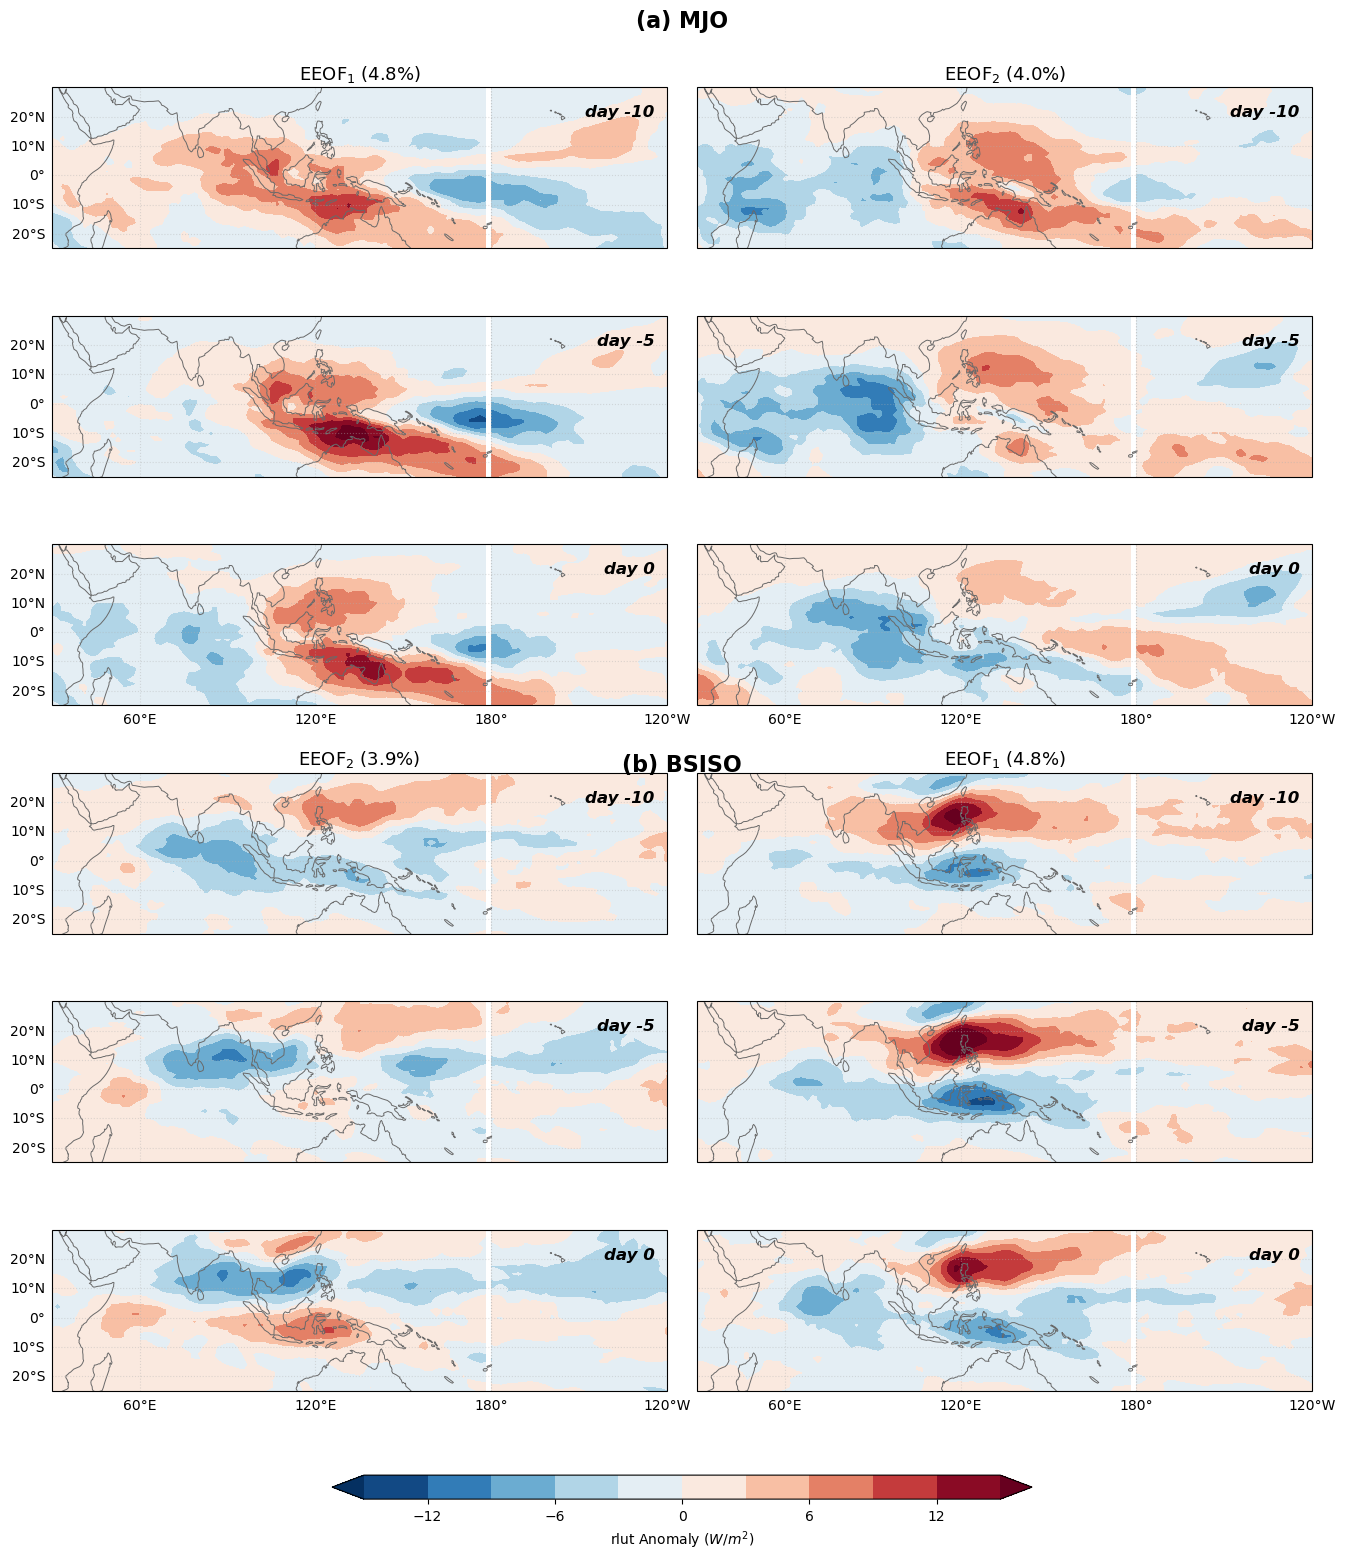

In [ ]:
# --- Plotting Evolution Map (Image_fd1502 Style) ---

map_proj = ccrs.PlateCarree(central_longitude=180)
data_proj = ccrs.PlateCarree()

fig, axes = plt.subplots(6, 2, figsize=(14, 16), subplot_kw={'projection': map_proj})
levels = np.linspace(-15, 15, 11)
cmap = 'RdBu_r'

configs = [
    {"title": "(a) MJO", "data": eeof_mjo, "vars": var_mjo, "modes": [0, 1], "start_row": 0},
    {"title": "(b) BSISO", "data": eeof_bsiso, "vars": var_bsiso, "modes": [1, 0], "start_row": 3}
]

for cfg in configs:
    patterns = cfg["data"]
    fig.text(0.5, 0.97 - (cfg["start_row"] * 0.155), cfg["title"], 
             ha='center', fontsize=16, fontweight='bold')
    
    for lag_idx, lag_val in enumerate(lags):
        row = cfg["start_row"] + lag_idx
        for col, mode_idx in enumerate(cfg["modes"]):
            ax = axes[row, col]
            plot_data = patterns.sel(mode=mode_idx).isel(lag=lag_idx)
            
            cf = ax.contourf(plot_data['lon'], plot_data['lat'], plot_data.values,
                             transform=data_proj, cmap=cmap, levels=levels, extend='both')
            
            ax.coastlines(color='dimgray', linewidth=0.7)
            ax.set_extent([30, 240, -25, 30], crs=data_proj)
            ax.text(0.98, 0.82, f'day {lag_val}', transform=ax.transAxes, 
                    fontsize=12, fontweight='bold', ha='right', style='italic')

            if lag_idx == 0:
                ax.set_title(f"EEOF$_{mode_idx+1}$ ({cfg['vars'][mode_idx]:.1f}%)", fontsize=13)

            gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.4)
            gl.top_labels = gl.right_labels = False
            if col != 0: gl.left_labels = False
            if row != 2 and row != 5: gl.bottom_labels = False

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.95, hspace=0.05, wspace=0.05)
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.015])
fig.colorbar(cf, cax=cbar_ax, orientation='horizontal', label='rlut Anomaly ($W/m^2$)')

# fld = '/home/189/fc6164/esmValTool/repos/bsiso_mjo/'
# plt.savefig(f"{fld}nosignflip_mjo_bsiso_patterns.png", dpi=300)
plt.show()

(a) MJO (Madden-Julian Oscillation)
- Movement: Primarily eastward along the equator.
- Structure: Symmetric about the equator (10S to 10 N).
- Day -10 to 0: Shows a clear progression of suppressed convection (red) and enhanced convection (blue) moving from the Indian Ocean toward the Western Pacific.

(b) BSISO (Boreal Summer Intraseasonal Oscillation)
- Movement: North-northeastward (slanted propagation).
- Structure: Extends much further north (up to 20 N), affecting the Asian Monsoon regions.
- Day -10 to 0: Convection cells move diagonally from the Indian Ocean toward South Asia and the South China Sea.


In [ ]:
# ======================================================
# --- Plotting Time Series with Amplitude Panel ---
# pc_bsiso_final will provide the PCs to the final plot
# ======================================================

def plot_pc_timeseries_with_amp(pc_mjo, pc_bsiso, start_year=2142, end_year=2173):
    # 1. Flip BSISO PC1 sign to stay consistent with the EEOF spatial flip
    # We do this before calculating amplitude to ensure the PC values are correct
    pc_bsiso_corrected = pc_bsiso.copy()
    pc_bsiso_corrected.loc[dict(mode=1)] = pc_bsiso_corrected.sel(mode=1) * -1

    # 2. Calculate Amplitudes
    amp_mjo = np.sqrt(pc_mjo.sel(mode=1)**2 + pc_mjo.sel(mode=2)**2)
    amp_bsiso = np.sqrt(pc_bsiso_corrected.sel(mode=1)**2 + pc_bsiso_corrected.sel(mode=2)**2)
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15), sharex=False)
    time_slice = slice(f"{start_year}-01-01", f"{end_year}-12-31")

    # --- MJO PCs Panel (DJF) ---
    m_slice = pc_mjo.sel(time=time_slice)
    # shift time/ change to timestamp for plotting (not cftime)
    m_slice = shift_time(m_slice, years=0)
    
    ax1.plot(m_slice.time, m_slice.sel(mode=1), label='PC1', color='royalblue', lw=1.2)
    ax1.plot(m_slice.time, m_slice.sel(mode=2), label='PC2', color='indianred', lw=1.2)
    ax1.set_title(f'MJO Principal Components (DJF) - {start_year} to {end_year}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Normalized PC')
    ax1.axhline(0, color='black', lw=0.8, ls='--')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # --- BSISO PCs Panel (JJA) ---
    # Use the corrected PC1 here
    b_slice = pc_bsiso_corrected.sel(time=time_slice)
    # shift time/ change to timestamp for plotting (not cftime)
    b_slice = shift_time(b_slice, years=0)
    
    ax2.plot(b_slice.time, b_slice.sel(mode=1), label='PC1 (Flipped)', color='royalblue', lw=1.2)
    ax2.plot(b_slice.time, b_slice.sel(mode=2), label='PC2', color='indianred', lw=1.2)
    ax2.set_title(f'BSISO Principal Components (JJA) - Corrected for EEOF1 Flip', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Normalized PC')
    ax2.axhline(0, color='black', lw=0.8, ls='--')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # --- Amplitude Panel (Combined) ---
    am_slice = shift_time(amp_mjo.sel(time=time_slice), years=0)
    ax3.plot(am_slice.time, am_slice, 
             label='MJO Amp (DJF)', color='navy', lw=2)
    ab_slice = shift_time(amp_bsiso.sel(time=time_slice), years=0)
    ax3.plot(ab_slice.time, ab_slice, 
             label='BSISO Amp (JJA)', color='darkorange', lw=2)
    
    ax3.axhline(1.0, color='red', lw=1.5, ls=':', label='Significance Threshold')
    
    ax3.set_title(r'ISO Amplitude ($\sqrt{PC1^2 + PC2^2}$)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Amplitude')
    
    # Dynamic limit for Y axis
    max_amp = np.nanmax([amp_mjo.max(), amp_bsiso.max()])
    ax3.set_ylim(0, max_amp + 0.5)
    ax3.legend(loc='upper right', ncol=3)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.show()
    
    return pc_bsiso_corrected # Returning this for use in the Phase Diagram

def shift_time(ds, years=1000):
    t = ds.time
    new_time = [
        pd.Timestamp(ti.year + years, ti.month, ti.day)
        for ti in t.values
    ]
    return ds.assign_coords(time=new_time)
    

In [ ]:
# Execute the plot and save the corrected PCs
pc_bsiso_final = plot_pc_timeseries_with_amp(pc_mjo, pc_bsiso, start_year='0296', end_year='0325')

In [ ]:
# save the corrected PCs
pc_bsiso_final = pc_bsiso.copy()
pc_bsiso_final.loc[dict(mode=1)] = pc_bsiso_corrected.sel(mode=1) * -1
# pc_bsiso.loc[dict(mode=1)] *= 1

In [ ]:
# ======================================================

def project_entire_year(da_full, eeof_da, lags=[-10, -5, 0]):
    """
    Projects the full year of data onto the fixed seasonal EEOF patterns.
    """
    # Create lagged fields for the entire dataset
    lagged_list = []
    for lag in lags:
        shifted = da_full.shift(time=-lag)
        shifted = shifted.expand_dims(lag=[lag])
        lagged_list.append(shifted)
    
    extended_full = xr.concat(lagged_list, dim='lag').dropna('time', how='any')
    
    # Apply area-weighting (consistent with EEOF)
    weights = np.sqrt(np.cos(np.deg2rad(extended_full['lat'])))
    weighted_full = extended_full * weights
    
    # Prepare data matrix (Time x Flattened Space-Lag)
    n_time = len(extended_full.time)
    matrix_full = weighted_full.transpose('time', 'lag', 'lat', 'lon').values.reshape(n_time, -1)
    
    # Flatten EEOF patterns (Mode x Flattened Space-Lag)
    flat_eeofs = eeof_da.values.reshape(2, -1)
    
    # Project: dot product (Data @ Patterns.T)
    # This gives us the raw PC scores for every day
    pcs_projected = np.dot(matrix_full, flat_eeofs.T)
    
    # Normalize to unit variance (standard practice for Amplitude thresholds)
    pcs_final = pcs_projected / pcs_projected.std(axis=0)
    
    return xr.DataArray(
        pcs_final,
        coords={'time': extended_full.time.values, 'mode': [1, 2]},
        dims=['time', 'mode']
    )


In [ ]:
# --- Execute Projection for the Whole Dataset ---
pc_mjo_all = project_entire_year(rlut_filtered, eeof_mjo, lags=lags)
pc_bsiso_all = project_entire_year(rlut_filtered, eeof_bsiso, lags=lags)

In [ ]:
# Calculate daily amplitudes for both modes year-round
amp_mjo = np.sqrt(pc_mjo_all.sel(mode=1)**2 + pc_mjo_all.sel(mode=2)**2)
amp_bsiso = np.sqrt(pc_bsiso_all.sel(mode=1)**2 + pc_bsiso_all.sel(mode=2)**2)

# Create a master DataFrame for classification
df_fig9 = pd.DataFrame({
    'time': pc_mjo_all.time.values,
    'amp_mjo': amp_mjo.values,
    'amp_bsiso': amp_bsiso.values
})


df_fig9['month'] = [ti.month for ti in df_fig9['time']]

In [ ]:
# Classification Logic:
# 1. Must be Significant (Amp >= 1.0)
# 2. If both significant, the one with the higher amplitude predominates
df_fig9['is_mjo'] = ((df_fig9['amp_mjo'] >= 1.0) & (df_fig9['amp_mjo'] > df_fig9['amp_bsiso'])).astype(int)
df_fig9['is_bsiso'] = ((df_fig9['amp_bsiso'] >= 1.0) & (df_fig9['amp_bsiso'] >= df_fig9['amp_mjo'])).astype(int)

# Group by month and calculate occurrence frequency
monthly_stats = df_fig9.groupby('month').agg({'is_mjo': 'mean', 'is_bsiso': 'mean'})

# Convert frequency to "Average Days per Month"
# (mean ratio * average days in that specific month)
days_in_month = np.array([31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
monthly_stats['mjo_days'] = monthly_stats['is_mjo'] * days_in_month
monthly_stats['bsiso_days'] = monthly_stats['is_bsiso'] * days_in_month

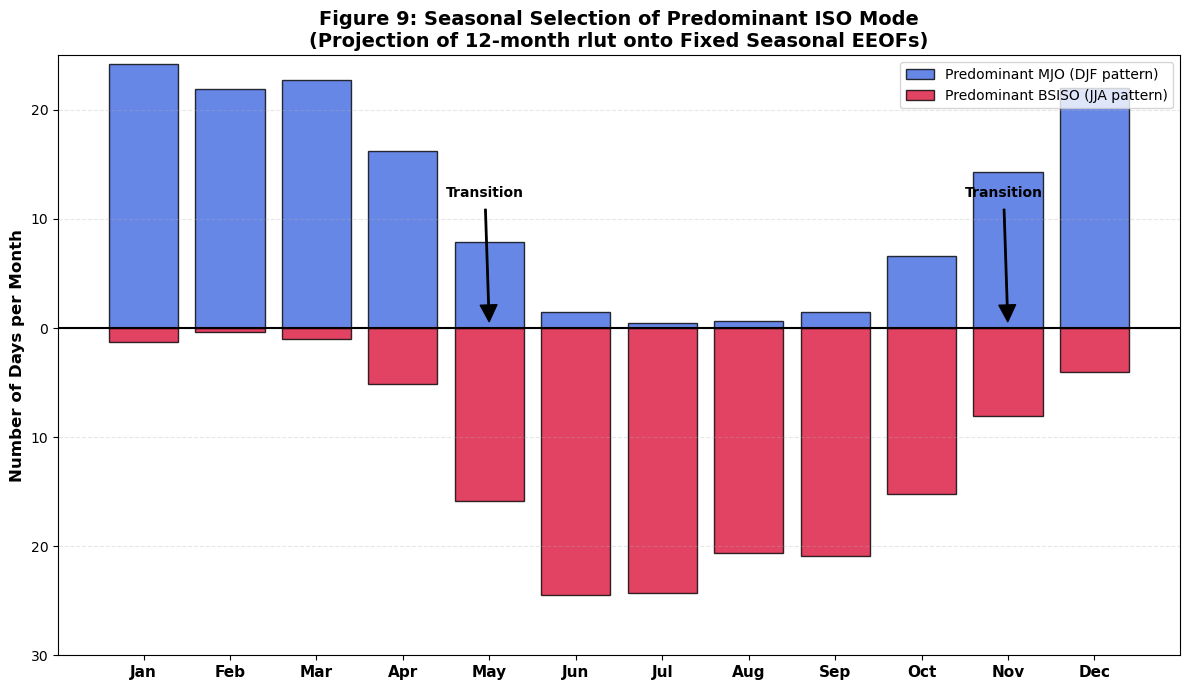

In [ ]:
plt.figure(figsize=(12, 7))
months_idx = np.arange(1, 13)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot MJO days (positive)
plt.bar(months_idx, monthly_stats['mjo_days'], color='royalblue', 
        edgecolor='black', alpha=0.8, label='Predominant MJO (DJF pattern)')

# Plot BSISO days (negative)
plt.bar(months_idx, -monthly_stats['bsiso_days'], color='crimson', 
        edgecolor='black', alpha=0.8, label='Predominant BSISO (JJA pattern)')

# Formatting
plt.axhline(0, color='black', linewidth=1.5)
plt.xticks(months_idx, month_labels, fontsize=11, fontweight='bold')

# Ensure Y-axis ticks are absolute (positive) values
ticks = plt.yticks()[0]
plt.yticks(ticks, [f'{int(abs(t))}' for t in ticks])

plt.ylim(-30, 25)  # Adjust based on your data density
plt.ylabel('Number of Days per Month', fontsize=12, fontweight='bold')
plt.title('Figure 9: Seasonal Selection of Predominant ISO Mode\n(Projection of 12-month rlut onto Fixed Seasonal EEOFs)', 
          fontsize=14, fontweight='bold')

# Legend and Grid
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add Annotation for Transitional Months
plt.annotate('Transition', xy=(5, 0), xytext=(4.5, 12),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontweight='bold')
plt.annotate('Transition', xy=(11, 0), xytext=(10.5, 12),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontweight='bold')

plt.tight_layout()
# plt.savefig(f"PI-CN_seasonal_mode.png", dpi=300)
plt.show()

**Seasonal Dominance**
- MJO (Blue Bars): Predominates during the Boreal Winter (December, January, and February). During these months, the eastward propagation you noticed earlier is the most frequent and strongest feature.
- BSISO (Red Bars): Predominates during the Boreal Summer (June, July, and August). This explains why the northeastward shift is the primary characteristic of intraseasonal variability during the summer monsoon season.

**Transition Periods** 
The chart explicitly marks two "Transition" phases where the atmosphere shifts between these two modes:
- May: The "handover" from the MJO-dominant winter pattern to the BSISO-dominant summer pattern.
- November: The return shift from the summer BSISO back to the winter MJO pattern.


In [ ]:
# ======================================================

# Calculate year-round amplitudes from the projected PCs
# (Consistent with your project_and_get_amp logic)
amp_mjo_val = np.sqrt(pc_mjo_all.sel(mode=1)**2 + pc_mjo_all.sel(mode=2)**2)
amp_bsiso_val = np.sqrt(pc_bsiso_all.sel(mode=1)**2 + pc_bsiso_all.sel(mode=2)**2)

# Create the DataFrame for plotting
df_scatter = pd.DataFrame({
    'MJO_Amp': amp_mjo_val.values,
    'BSISO_Amp': amp_bsiso_val.values,
    'month': pc_mjo_all.time.dt.month.values
}, index=pc_mjo_all.time.values)

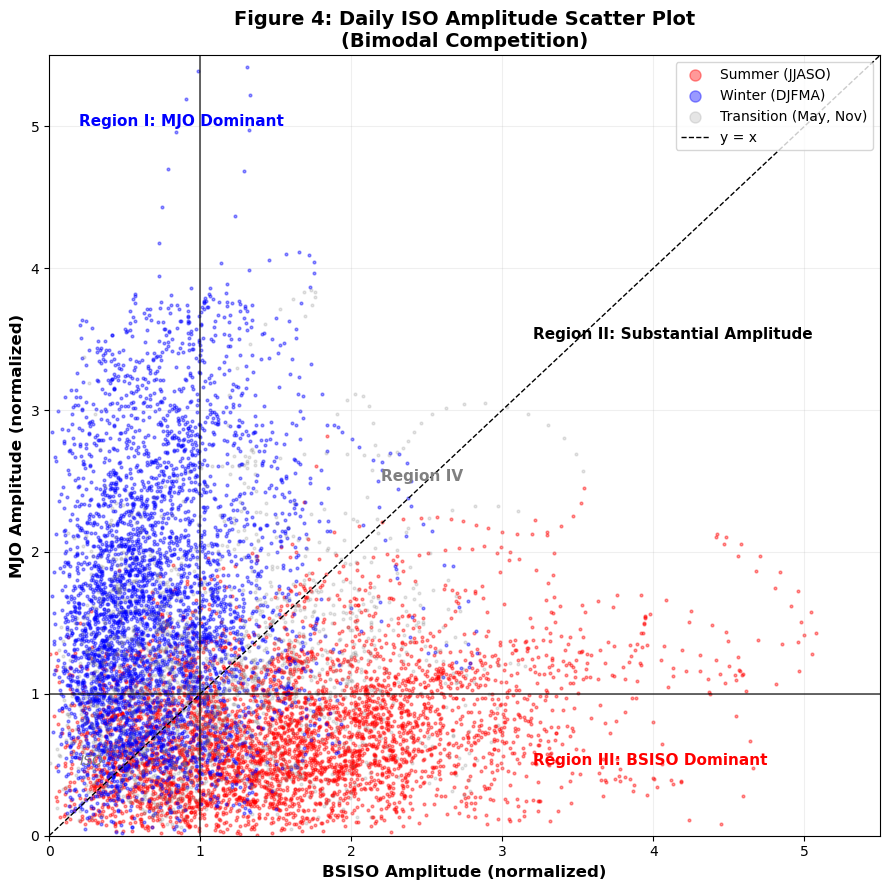

In [ ]:
plt.figure(figsize=(9, 9))

# --- Plotting by Season ---

# 1. Summer (JJASO): Red
summer_mask = df_scatter['month'].isin([6, 7, 8, 9, 10])
plt.scatter(df_scatter.loc[summer_mask, 'BSISO_Amp'], 
            df_scatter.loc[summer_mask, 'MJO_Amp'], 
            c='red', s=4, alpha=0.4, label='Summer (JJASO)', rasterized=True)

# 2. Winter (DJFMA): Blue
winter_mask = df_scatter['month'].isin([12, 1, 2, 3, 4])
plt.scatter(df_scatter.loc[winter_mask, 'BSISO_Amp'], 
            df_scatter.loc[winter_mask, 'MJO_Amp'], 
            c='blue', s=4, alpha=0.4, label='Winter (DJFMA)', rasterized=True)

# 3. Transition (May, Nov): Grey
trans_mask = df_scatter['month'].isin([5, 11])
plt.scatter(df_scatter.loc[trans_mask, 'BSISO_Amp'], 
            df_scatter.loc[trans_mask, 'MJO_Amp'], 
            c='gray', s=4, alpha=0.2, label='Transition (May, Nov)', rasterized=True)

# --- Reference Lines ---
plt.axhline(1.0, color='black', lw=1.2, linestyle='-', alpha=0.7) # MJO Threshold
plt.axvline(1.0, color='black', lw=1.2, linestyle='-', alpha=0.7) # BSISO Threshold
plt.plot([0, 6], [0, 6], color='black', linestyle='--', lw=1, label='y = x') # 1:1 Line

# --- Chart Formatting ---
plt.xlim(0, 5.5)
plt.ylim(0, 5.5)
plt.xlabel('BSISO Amplitude (normalized)', fontsize=12, fontweight='bold')
plt.ylabel('MJO Amplitude (normalized)', fontsize=12, fontweight='bold')
plt.title('Figure 4: Daily ISO Amplitude Scatter Plot\n(Bimodal Competition)', fontsize=14, fontweight='bold')

# Legend with larger markers for visibility
plt.legend(markerscale=4, loc='upper right', frameon=True)
plt.grid(alpha=0.2)

# --- Region Annotations ---
plt.text(0.2, 5.0, 'Region I: MJO Dominant', fontsize=11, color='blue', fontweight='bold')
plt.text(3.2, 0.5, 'Region III: BSISO Dominant', fontsize=11, color='red', fontweight='bold')
plt.text(3.2, 3.5, 'Region II: Substantial Amplitude', fontsize=11, color='k', fontweight='bold')
plt.text(2.2, 2.5, 'Region IV', fontsize=11, color='gray', fontweight='bold')
plt.text(0.2, 0.5, 'ISO', fontsize=10, color='gray', style='italic')

plt.tight_layout()
# plt.savefig(f"PI-CN_iso_amp_scatter.png", dpi=300)
plt.show()

1. Bimodal Competition (The y=x Line)

The chart plots MJO Amplitude (y-axis) against BSISO Amplitude (x-axis). The diagonal dashed line (y=x) represents the boundary where both modes have equal strength. Points further from this line indicate one mode is significantly stronger than the other.

2. Seasonal Dominance

Region I (MJO Dominant): Located in the upper-left, dominated by blue dots representing Winter (DJFMA). This shows that during winter, the MJO is much stronger than the BSISO.
Region III (BSISO Dominant): Located in the lower-right, dominated by red dots representing Summer (JJASO). This confirms that BSISO is the primary driver during the summer months.

3. Transition & Substantial Amplitude

Region II: Represents days where both MJO and BSISO have "Substantial Amplitude" (both exceeding a normalized value of 1). Even here, the colours show a clear seasonal split.
Transition Months (Grey dots): Points for May and November are scattered near the origin or along the transition zones, representing the period when the atmosphere switches between winter and summer patterns.


In [ ]:
# ======================================================
# 1. Define the period
plot_start, plot_end = "0296-01-01", "0325-12-31"

# 2. Extract data (Using pc_bsiso_final which contains the PC1 sign flip)
mjo_sub = pc_mjo.sel(time=slice(plot_start, plot_end))
bsiso_sub = pc_bsiso_final.sel(time=slice(plot_start, plot_end))

In [ ]:
def plot_phase_space(ax, pc_da, title, color_map, is_bsiso=True):
    # Ensure we use the correct PC mapping for the axes
    pc1 = pc_da.sel(mode=1).values
    pc2 = pc_da.sel(mode=2).values
    amp = np.sqrt(pc1**2 + pc2**2)
    
    # Trajectory and Scatter
    ax.plot(pc1, pc2, color='gray', lw=0.8, alpha=0.3, zorder=1)
    sc = ax.scatter(pc1, pc2, c=amp, cmap=color_map, s=10, zorder=2, alpha=0.6)
    
    # Unit Circle (Threshold)
    circle = plt.Circle((0, 0), 1, color='black', fill=False, lw=1.5, zorder=3)
    ax.add_artist(circle)
    
    # Phase Boundaries (8-sector wheel)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(0, color='black', lw=1.2)
    ax.plot([-5, 5], [-5, 5], color='black', lw=1.2)
    ax.plot([-5, 5], [5, -5], color='black', lw=1.2)
    
    # --- Geographical Labels (Paper Specific) ---
    label_style = {'fontsize': 11, 'fontweight': 'bold', 'ha': 'center', 'va': 'center'}
    
    if is_bsiso:
        ax.text(0, -4.6, "Bay of Bengal", **label_style)
        ax.text(4.6, 0, "India\n& Maritime Continent", rotation=-90, **label_style)
        ax.text(0, 4.6, "Western North Pacific", **label_style)
        ax.text(-4.6, 0, "Eastern North Pacific\n& Equatorial Indian Ocean", rotation=90, **label_style)
    else:
        ax.text(-4.6, 0, "Central Pacific\n& Africa-Western Indian Ocean", rotation=90, **label_style)
        ax.text(0, -4.6, "Eastern Indian Ocean", **label_style)
        ax.text(4.6, 0, "Maritime Continent", rotation=-90, **label_style)
        ax.text(0, 4.6, "Western Pacific", **label_style)

    # Formatting
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # Phase Numbers (1-8)
    # Re-ordered sequence to match standard anti-clockwise propagation logic
    phases = ['5', '6', '7', '8', '1', '2', '3', '4']
    angles = np.linspace(np.pi, -np.pi, 9)[:-1] + (np.pi/8)
    for i, label in enumerate(phases):
        x_num, y_num = 3.8 * np.cos(angles[i]), 3.8 * np.sin(angles[i])
        ax.text(x_num, y_num, label, fontsize=12, fontweight='bold', color='black', alpha=0.5)
        
    return sc

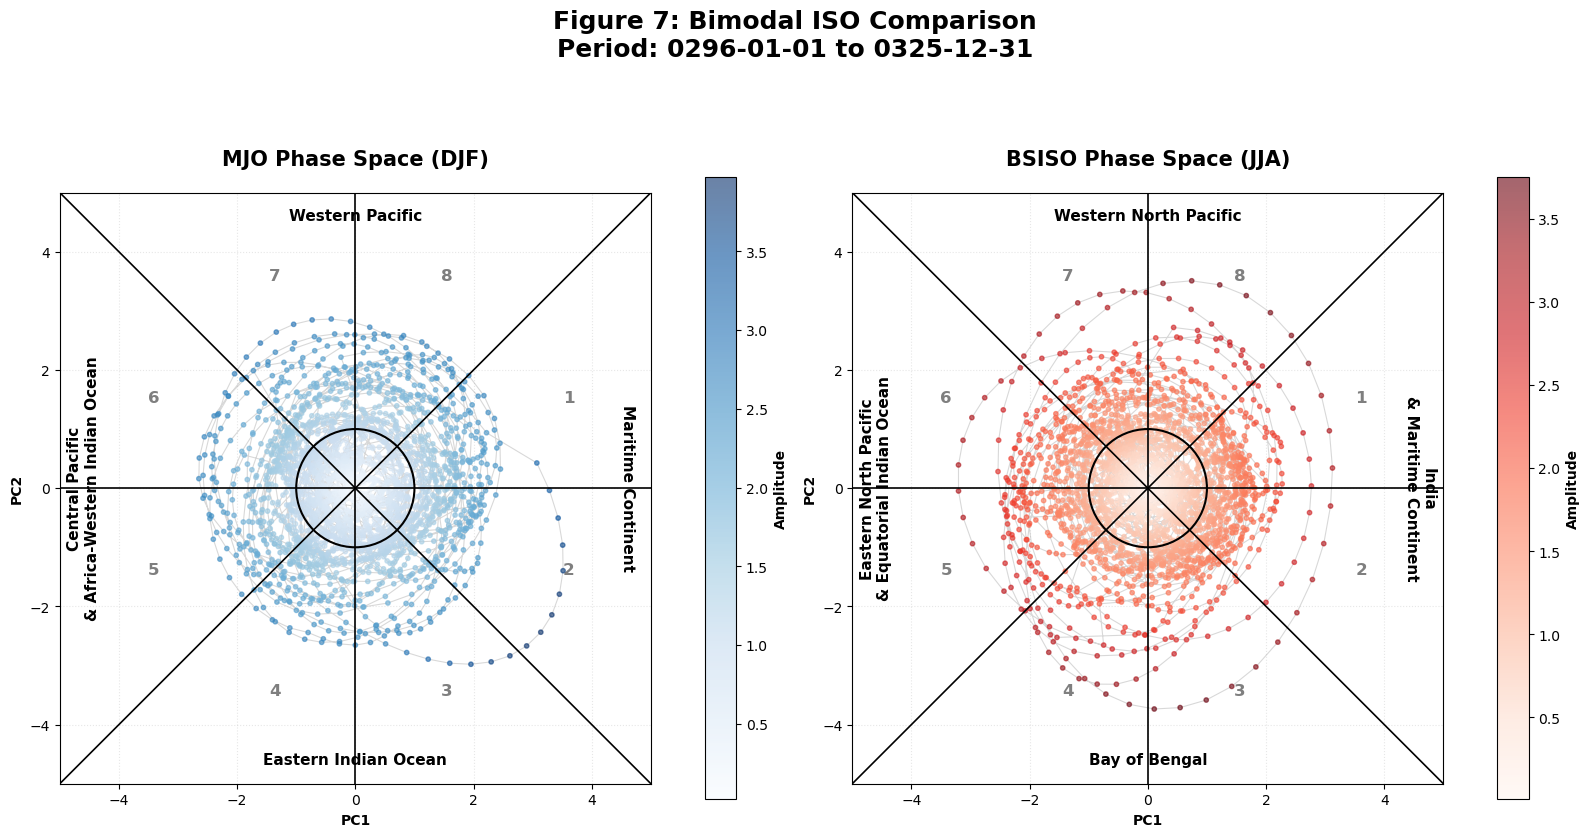

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))
# --- Execute Plotting ---
sc1 = plot_phase_space(ax1, mjo_sub, 'MJO Phase Space (DJF)', 'Blues', is_bsiso=False)
sc2 = plot_phase_space(ax2, bsiso_sub, 'BSISO Phase Space (JJA)', 'Reds', is_bsiso=True)

# Labels
ax1.set_xlabel('PC1', fontweight='bold')
ax1.set_ylabel('PC2', fontweight='bold')
ax2.set_xlabel('PC1', fontweight='bold')
ax2.set_ylabel('PC2', fontweight='bold')

# Colorbars
cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.08)
cbar1.set_label('Amplitude', fontweight='bold')
cbar2 = fig.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.08)
cbar2.set_label('Amplitude', fontweight='bold')

plt.suptitle(f'Figure 7: Bimodal ISO Comparison\nPeriod: {plot_start} to {plot_end}', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
# plt.savefig(f"PI-CN_mjo_psiso_phase.png", dpi=300)
plt.show()

1. MJO Phase Space (DJF)
- Propagation: The circular, counter-clockwise tracks show the MJO moving through its 8 phases.
- Geography: It transitions from the Indian Ocean (Phases 2-3) through the Maritime Continent (Phases 4-5) to the Western Pacific (Phases 6-7).
- Intensity: Darker blue dots further from the centre represent stronger amplitude events during the winter months.
2. BSISO Phase Space (JJA)
- Propagation: Similar circular tracks represent the summer intraseasonal cycle.
- Geography: The phases track movement through the Bay of Bengal (Phases 3-4), India & Maritime Continent (Phases 1-2), and the Western North Pacific (Phases 7-8).
- Intensity: Darker red dots indicate high-amplitude BSISO events, which are more frequent during the summer months.
3. Key Insights
- Bimodal Competition: These diagrams confirm that the MJO is the dominant mode in winter (DJF), while the BSISO takes over in summer (JJA).
- Predictability: The organized circular nature of these plots indicates that both oscillations are highly periodic and predictable once they reach a "substantial amplitude" (outside the inner unit circle).
